# Certs overview

In [1]:
# Some imports
from cryptography.hazmat.backends import default_backend
from cryptography.hazmat.primitives import serialization
from cryptography.x509.oid import NameOID
import matplotlib.pyplot as plt
from cryptography import x509
import statistics
import collections
import pandas
import numpy
import json

In [2]:
# Load certificates
certs = list()
with open("../data/certificates/certificates.json", "r") as f:
    for line in f:
        cert_str = json.loads(line)
        pem_bytes = cert_str.encode('utf-8')
        cert = x509.load_pem_x509_certificate(pem_bytes, default_backend())
        certs.append(cert)

### Issuers (whole year)

In [3]:
# Extract all the certificare issuers (org + country)
issuer_orgs = list()
for cert in certs:
    issuer_org, issuer_cc = None, None
    for attribute in cert.issuer:
        if attribute.oid == NameOID.ORGANIZATION_NAME:
            issuer_org = attribute.value
        elif attribute.oid == NameOID.COUNTRY_NAME:
            issuer_cc = attribute.value
    issuer_orgs.append((issuer_org,issuer_cc))

# Count all the issuers
issuer_orgs_count = collections.Counter(issuer_orgs).most_common()
countries = {i[0][1] for i in issuer_orgs_count}
print(f"There are {len(issuer_orgs_count)} issuer organizations from {len(countries)} countries:")
for org,count in issuer_orgs_count:
    print(f"  {org[0]} ({org[1]}): {count:,}")

There are 46 issuer organizations from 14 countries:
  ZeroSSL (AT): 312,816
  Let's Encrypt (US): 186,390
  Google Trust Services (US): 14,394
  Sectigo Limited (GB): 1,775
  Unizeto Technologies S.A. (PL): 449
  SSL Corporation (US): 367
  GlobalSign nv-sa (BE): 360
  DigiCert Inc (US): 316
  Asseco Data Systems S.A. (PL): 149
  ZoTrus Technology Limited (CN): 80
  广东堡塔安全技术有限公司 (CN): 71
  GoGetSSL (LV): 50
  sslTrus (CN): 49
  CerSign Technology Limited (CN): 40
  WoTrus CA Limited (CN): 32
  SSL Corp (US): 30
  TAIWAN-CA (TW): 26
  DigiCert, Inc. (US): 21
  NYA LABS LLC (US): 21
  Cybertrust Japan Co., Ltd. (JP): 21
  UniTrust (CN): 19
  TrustAsia Technologies, Inc. (CN): 18
  DNSPod, Inc. (CN): 16
  Entrust, Inc. (US): 15
  泰尔认证中心有限公司 (CN): 14
  Alpiro s.r.o. (CZ): 12
  Beijing Xinchacha Credit Management Co., Ltd. (CN): 11
  LATSSL (Intradigital Soluciones Tecnologicas S. de R.L. de C.V) (MX): 6
  JoySSL Limited (CN): 6
  China Financial Certification Authority (CN): 6
  PKI(Chong

In [4]:
top_2_ca_certs = sum([i[1] for i in issuer_orgs_count[:2]])
print(f"The top 2 CAs account for {top_2_ca_certs:,} ({round(top_2_ca_certs*100/len(certs),2)}%) certificates out of {len(certs):,}")

The top 2 CAs account for 499,206 (96.44%) certificates out of 517,619


In [5]:
# Print the above data as a LaTeX table
line_num = 1
for org, count in issuer_orgs_count:
    print(f"{line_num}. & {org[0]} & {org[1]} & {count:,} \\\\")
    line_num += 1

1. & ZeroSSL & AT & 312,816 \\
2. & Let's Encrypt & US & 186,390 \\
3. & Google Trust Services & US & 14,394 \\
4. & Sectigo Limited & GB & 1,775 \\
5. & Unizeto Technologies S.A. & PL & 449 \\
6. & SSL Corporation & US & 367 \\
7. & GlobalSign nv-sa & BE & 360 \\
8. & DigiCert Inc & US & 316 \\
9. & Asseco Data Systems S.A. & PL & 149 \\
10. & ZoTrus Technology Limited & CN & 80 \\
11. & 广东堡塔安全技术有限公司 & CN & 71 \\
12. & GoGetSSL & LV & 50 \\
13. & sslTrus & CN & 49 \\
14. & CerSign Technology Limited & CN & 40 \\
15. & WoTrus CA Limited & CN & 32 \\
16. & SSL Corp & US & 30 \\
17. & TAIWAN-CA & TW & 26 \\
18. & DigiCert, Inc. & US & 21 \\
19. & NYA LABS LLC & US & 21 \\
20. & Cybertrust Japan Co., Ltd. & JP & 21 \\
21. & UniTrust & CN & 19 \\
22. & TrustAsia Technologies, Inc. & CN & 18 \\
23. & DNSPod, Inc. & CN & 16 \\
24. & Entrust, Inc. & US & 15 \\
25. & 泰尔认证中心有限公司 & CN & 14 \\
26. & Alpiro s.r.o. & CZ & 12 \\
27. & Beijing Xinchacha Credit Management Co., Ltd. & CN & 11 \\
28. & 

### Issuers (before and after Let's Encrypt)

In [6]:
# Extract all the certificare issuers (org + country)
issuer_orgs_first_half, issuer_orgs_second_half = list(), list()
for cert in certs:
    issuer_org, issuer_cc = None, None
    for attribute in cert.issuer:
        if attribute.oid == NameOID.ORGANIZATION_NAME:
            issuer_org = attribute.value
        elif attribute.oid == NameOID.COUNTRY_NAME:
            issuer_cc = attribute.value
    
    if cert.not_valid_before_utc.month in {1,2,3,4,5,6}:
        issuer_orgs_first_half.append((issuer_org,issuer_cc))
    else:
        issuer_orgs_second_half.append((issuer_org,issuer_cc))

# Count all the issuers before July and after
issuer_orgs_count_first_half = collections.Counter(issuer_orgs_first_half).most_common(n=5)
print("Before July 1, 2025:")
for org,count in issuer_orgs_count_first_half:
    print(f"  {org[0]} ({org[1]}): {count:,}")
issuer_orgs_count_second_half = collections.Counter(issuer_orgs_second_half).most_common(n=5)
print("")
print("After July 1, 2025:")
for org,count in issuer_orgs_count_second_half:
    print(f"  {org[0]} ({org[1]}): {count:,}")

Before July 1, 2025:
  ZeroSSL (AT): 179,881
  Google Trust Services (US): 6,431
  Sectigo Limited (GB): 1,119
  Unizeto Technologies S.A. (PL): 298
  GlobalSign nv-sa (BE): 240

After July 1, 2025:
  Let's Encrypt (US): 186,390
  ZeroSSL (AT): 132,935
  Google Trust Services (US): 7,963
  Sectigo Limited (GB): 656
  SSL Corporation (US): 190


In [7]:
# Print the above data as a LaTeX tables
line_num = 1
for org, count in issuer_orgs_count_first_half:
    print(f"{line_num}. & {org[0]} & {org[1]} & {count:,} \\\\")
    line_num += 1

print("")
line_num = 1
for org, count in issuer_orgs_count_second_half:
    print(f"{line_num}. & {org[0]} & {org[1]} & {count:,} \\\\")
    line_num += 1

1. & ZeroSSL & AT & 179,881 \\
2. & Google Trust Services & US & 6,431 \\
3. & Sectigo Limited & GB & 1,119 \\
4. & Unizeto Technologies S.A. & PL & 298 \\
5. & GlobalSign nv-sa & BE & 240 \\

1. & Let's Encrypt & US & 186,390 \\
2. & ZeroSSL & AT & 132,935 \\
3. & Google Trust Services & US & 7,963 \\
4. & Sectigo Limited & GB & 656 \\
5. & SSL Corporation & US & 190 \\


### Monthly issuer stats

In [8]:
# First prepare the data
certs_monthly = collections.defaultdict(lambda: collections.defaultdict(int))
# Top 4 issuers
top_4_ca_names = [i[0][0] for i in issuer_orgs_count[:4]]

for cert in certs:
    # Find the month of notBefore
    not_before = cert.not_valid_before_utc.month
    # Find the issuer org
    for attribute in cert.issuer:
        if attribute.oid == NameOID.ORGANIZATION_NAME:
            issuer_org = attribute.value

    # Only print names of top issuers
    if issuer_org in top_4_ca_names:
        certs_monthly[not_before][issuer_org] += 1
    else:
        certs_monthly[not_before]["Others"] += 1

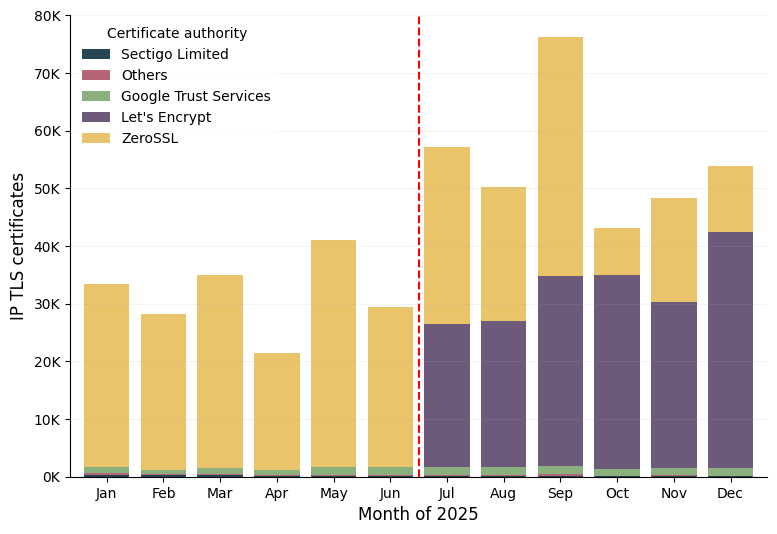

In [9]:
# Plot the above data

df = pandas.DataFrame(certs_monthly).T.fillna(0).astype(int)
df = df.sort_index()
df = df[df.sum().sort_values(ascending=True).index]

colors = ["#264653","#B56576","#8AB17D","#6D597A", "#E9C46A"]
fig, ax = plt.subplots(figsize=(9, 6))
df.plot(kind='bar', stacked=True, color=colors, width=0.8, edgecolor='none', ax=ax)

# Labels
ax.set_xlabel('Month of 2025', fontsize=12)
ax.set_ylabel('IP TLS certificates', fontsize=12)

# Axes
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax.set_xticks(range(len(df.index)))
ax.set_xticklabels(month_labels[:len(df.index)], rotation=0)
y_ticks = numpy.arange(0, 90000, 10000)
ax.set_yticks(y_ticks)
ax.set_yticklabels([f"{int(y/1000)}K" for y in y_ticks])

# Grid and some styling
ax.grid(axis='y', linewidth=0.5, alpha=0.2)
ax.grid(axis='x', visible=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Delimit Let's Encrypt
ax.axvline(x=5.5, color='red', linestyle='--', linewidth=1.5, zorder=10)

# Legend
ax.legend(title="Certificate authority", loc='upper left', frameon=True, facecolor='white', edgecolor='none')

plt.savefig(f"../data/figures/monthly_certificate_distribution.pdf",bbox_inches='tight')
plt.show()

### Certificate validity

In [10]:
# Compute certificate validity for all certs
cert_validity_all, cert_validity_hours_all = list(), list()

# Store the issuers and their validities
issuer_validity = collections.defaultdict(list)

# Store validities (in days) and their issuers
validity_issuer = collections.defaultdict(list)

for cert in certs:
    # First identify the org
    for attribute in cert.issuer:
        if attribute.oid == NameOID.ORGANIZATION_NAME:
            issuer_org = attribute.value
    # Compute the delta and convert to hours
    delta = cert.not_valid_after_utc - cert.not_valid_before_utc
    delta_hours = int(delta.total_seconds() // 3600)
    # Store for all issuers
    cert_validity_all.append(delta)
    cert_validity_hours_all.append(delta_hours)
    issuer_validity[issuer_org].append(delta)
    # Store validities
    validity_issuer[delta.days].append(issuer_org)

print(f"All certificates: {len(cert_validity_all):,} ({len(set(cert_validity_all))} different values)")
print(f"  Minimum validity: {min(cert_validity_all)}")
print(f"  Maximum validity: {max(cert_validity_all)}")
print(f"  Mean validity: {statistics.mean(cert_validity_hours_all)} hours")
print(f"  Median validity: {statistics.median(cert_validity_hours_all)} hours")

All certificates: 517,619 (482 different values)
  Minimum validity: 1 day, 23:59:59
  Maximum validity: 396 days, 23:59:59
  Mean validity: 1445.631846976251 hours
  Median validity: 2183 hours


In [11]:
print(f"Most common validities in days:")
for validity,count in sorted([(i,len(validity_issuer[i])) for i in validity_issuer], key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {validity} days: {count:,} certificates")
    for ca,count in collections.Counter(validity_issuer[validity]).most_common(n=5):
        print(f"    {ca,count}")

Most common validities in days:
  90 days: 312,759 certificates
    ('ZeroSSL', 312405)
    ('Sectigo Limited', 134)
    ('ZoTrus Technology Limited', 79)
    ('SSL Corporation', 50)
    ('CerSign Technology Limited', 40)
  6 days: 200,705 certificates
    ("Let's Encrypt", 186390)
    ('Google Trust Services', 14315)
  365 days: 1,039 certificates
    ('Sectigo Limited', 595)
    ('ZeroSSL', 298)
    ('sslTrus', 25)
    ('WoTrus CA Limited', 17)
    ('DigiCert Inc', 17)
  396 days: 835 certificates
    ('GlobalSign nv-sa', 335)
    ('SSL Corporation', 282)
    ('Sectigo Limited', 111)
    ('DigiCert Inc', 74)
    ('sslTrus', 10)
  364 days: 495 certificates
    ('Unizeto Technologies S.A.', 161)
    ('DigiCert Inc', 124)
    ('Asseco Data Systems S.A.', 82)
    ('广东堡塔安全技术有限公司', 63)
    ('泰尔认证中心有限公司', 13)


In [12]:
# Print the distribution of deltas for top 5 issuers
for i in issuer_orgs_count[:5]:
    org = i[0][0]
    validity_counter = collections.Counter(issuer_validity[org]).most_common(5)
    print(f"{org} ({len(issuer_validity[org]):,} certs in total)")
    for delta,count in validity_counter:
        print(f"  {delta}: {count:,}")
    print(f"")

ZeroSSL (312,816 certs in total)
  90 days, 23:59:59: 312,405
  365 days, 23:59:59: 298
  91 days, 23:59:59: 113

Let's Encrypt (186,390 certs in total)
  6 days, 15:59:59: 186,390

Google Trust Services (14,394 certs in total)
  6 days, 23:00:00: 14,315
  83 days, 23:59:59: 79

Sectigo Limited (1,775 certs in total)
  365 days, 23:59:59: 595
  395 days, 23:59:59: 157
  90 days, 23:59:59: 134
  396 days, 23:59:59: 111
  74 days, 23:59:59: 20

Unizeto Technologies S.A. (449 certs in total)
  394 days, 23:59:59: 280
  364 days, 23:59:59: 151
  364 days, 18:05:44: 1
  365 days, 7:07:29: 1
  364 days, 17:11:42: 1



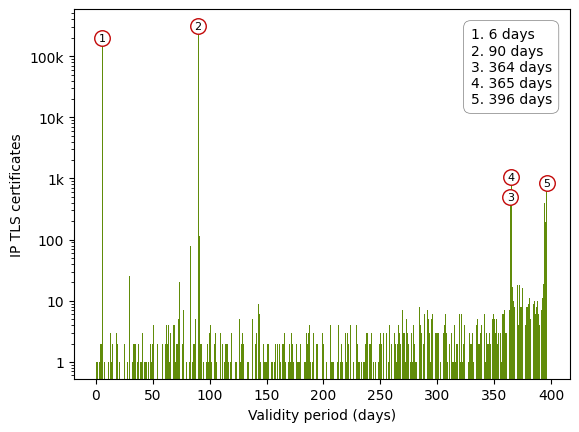

In [13]:
# Data to plot
validity_days = [td.days for td in cert_validity_all]
validity_counts = collections.Counter(validity_days)

x = sorted(validity_counts.keys())
y = [validity_counts[i] for i in x]

# Highlight top 5 durations
top_5_indices = sorted(sorted(range(len(y)), key=lambda i: y[i])[-5:])
top_5_indices = sorted(sorted(range(len(y)), key=lambda i: y[i])[-5:])
top_x = [x[i] for i in top_5_indices]
top_y = [y[i] for i in top_5_indices]
plt.scatter(top_x, top_y, s=125, facecolors=(1, 1, 1, 1), edgecolors='#c20808', linewidth=1, zorder=10)

for n, (x_val, y_val) in enumerate(zip(top_x, top_y), start=1):
    plt.annotate(str(n),(x_val, y_val),ha='center',va='center',fontsize=8,fontweight='medium',zorder=11)
legend_text = '\n'.join(f'{n}. {x_val} days'for n, x_val in enumerate(top_x, start=1))
plt.gca().text(0.8, 0.95,legend_text,transform=plt.gca().transAxes,va='top',ha='left',
    bbox=dict(boxstyle='round,pad=0.5',facecolor='white',edgecolor='gray',linewidth=0.5))

plt.bar(x, y, color='#618c0a')
plt.yscale("log")
plt.yticks([1, 10, 100, 1000, 10000, 100000], ["1", "10", "100", "1k", "10k", "100k"]) 
plt.xlabel("Validity period (days)")
plt.ylabel("IP TLS certificates")

plt.savefig(f"../data/figures/certificate_validity.pdf",bbox_inches='tight')
plt.show()

### Signatures

In [14]:
signatures, signature_algorithms = list(), list()

for cert in certs:
    # Get signatures
    signature = cert.signature
    signatures.append(signature)
    # Get signature algorithms
    signature_algo = cert.signature_hash_algorithm.name
    signature_algorithms.append(signature_algo)


print(f"{len(set(signatures)):,} out of {len(signatures):,} signatures are unique")
print(f"")
print(f"Signature algorithms:")
for algo,count in collections.Counter(signature_algorithms).most_common():
    print(f"  {algo}: {count:,} ({round(count*100/len(signature_algorithms),2)}%)")


517,619 out of 517,619 signatures are unique

Signature algorithms:
  sha384: 405,777 (78.39%)
  sha256: 111,841 (21.61%)
  sha512: 1 (0.0%)


### Public keys

In [15]:
# Get the count of certificates per public key
public_keys_certs = collections.defaultdict(int)
for cert in certs:
    # Get the key as a string
    public_key = cert.public_key().public_bytes(
        encoding=serialization.Encoding.PEM,
        format=serialization.PublicFormat.SubjectPublicKeyInfo
    ).decode()
    public_keys_certs[public_key] += 1

# Get the list of reused keys
public_keys_reused = [i for i in public_keys_certs if public_keys_certs[i] > 1]

# For each reused key, find issuer orgs using it
public_keys_reused_issuers = collections.defaultdict(set)
for cert in certs:
    # Get the key as a string
    public_key = cert.public_key().public_bytes(
        encoding=serialization.Encoding.PEM,
        format=serialization.PublicFormat.SubjectPublicKeyInfo
    ).decode()
    if public_key in public_keys_reused:
        # Get the issuer
        for attribute in cert.issuer:
            if attribute.oid == NameOID.ORGANIZATION_NAME:
                issuer_org = attribute.value
        public_keys_reused_issuers[public_key].add(issuer_org)

# Analyze keys with different issuers
public_keys_reused_multiple_issuers = [i for i in public_keys_reused_issuers if len(public_keys_reused_issuers[i]) > 1]

print(f"There were {len(public_keys_certs):,} unique public keys among {len(certs):,} certificates")
print(f"  There were {len(public_keys_reused):,} reused keys:")
print(f"    {len(public_keys_reused_multiple_issuers)} keys are reused between issuers")

There were 502,813 unique public keys among 517,619 certificates
  There were 1,082 reused keys:
    3 keys are reused between issuers


In [16]:
# Case study: analyze the cases of key reuse among Certificate Authorities
public_keys_multiple_issuers = collections.defaultdict(list)

for cert in certs:
    public_key = cert.public_key().public_bytes(
        encoding=serialization.Encoding.PEM,
        format=serialization.PublicFormat.SubjectPublicKeyInfo
    ).decode()
    if public_key in public_keys_reused_multiple_issuers:
        my_cert = (cert.issuer.get_attributes_for_oid(NameOID.ORGANIZATION_NAME)[0].value,cert.subject.get_attributes_for_oid(NameOID.COMMON_NAME)[0].value,cert.not_valid_before_utc.date(),cert.not_valid_after_utc.date())
        public_keys_multiple_issuers[public_key].append(my_cert)

count = 1
for public_key in public_keys_multiple_issuers:
    print(f"Reused key {count}:")
    for cert in public_keys_multiple_issuers[public_key]:
        print(f" {cert[0]} ({cert[1]}) from {cert[2]} to {cert[3]}")
    count += 1
    print(f"")

Reused key 1:
 ZeroSSL (101.47.38.15) from 2025-10-02 to 2025-12-31
 SSL Corporation (101.47.38.15) from 2025-07-03 to 2025-10-01

Reused key 2:
 ZeroSSL (197.232.33.44) from 2025-05-28 to 2025-08-26
 Sectigo Limited (197.232.33.44) from 2025-04-11 to 2025-05-16

Reused key 3:
 ZeroSSL (143.110.178.44) from 2025-06-19 to 2025-09-17
 Sectigo Limited (143.110.178.44) from 2025-09-12 to 2026-10-13

